In [1]:
import os
import glob
import json
import cv2

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

import stackview
from PIL import Image
from sklearn.metrics import r2_score, roc_curve, auc

from zod import ZodFrames
from zod.constants import AnnotationProject, Camera
from zod.visualization.object_visualization import overlay_object_2d_box_on_image
from zod.anno.object import Box2D

plt.style.use('default')
sns.set_palette("husl")

SEED = 43
np.random.seed(SEED)

# Load Data

In [2]:
model = "faster-rcnn"
IMG_SIZE = (1344, 756)

In [3]:
base_data_path_file = f"{model}_metafeatures.csv"

iou_assessor_results = pd.read_csv("../results/assessors/iou_test_ass_" + base_data_path_file, index_col=0)
lrp_assessor_results = pd.read_csv("../results/assessors/lrp_test_ass_" + base_data_path_file, index_col=0)

print(iou_assessor_results.head(5))


   country time_of_day        lat       long  solar_angle_elevation  month  \
1       PL         day  52.249511  21.043137              51.723833      4   
6       PL         day  52.239332  21.030383              42.398401      4   
49      PL         day  52.224666  21.071192              51.883848      4   
52      PL    twilight  52.231355  21.054809              -2.536789      4   
54      PL         day  52.257694  20.994291              44.128632      4   

    hour  forward_acceleration  lateral_acceleration  forward_velocity  ...  \
1     10              2.183310             -0.223677         37.171527  ...   
6      8              0.128747             -0.984582          0.145631  ...   
49    10              0.347431             -0.483812          0.036762  ...   
52    17              0.015482             -0.583593         25.410050  ...   
54     8              3.068446             -0.079206         36.614314  ...   

    mean_conf  std_conf        GT  baseline        lr   

In [4]:
iou_assessor_results.columns

Index(['country', 'time_of_day', 'lat', 'long', 'solar_angle_elevation',
       'month', 'hour', 'forward_acceleration', 'lateral_acceleration',
       'forward_velocity', 'lateral_velocity', 'field_view_horizontal',
       'camera_distance_from_ground', 'camera_pitch_angle',
       'distortion_magnitude', 'camera_offset', 'laplacian', 'quality',
       'brightness', 'noisiness', 'sharpness', 'contrast', 'complexity',
       'num_detections', 'max_conf', 'min_conf', 'mean_conf', 'std_conf', 'GT',
       'baseline', 'lr', 'dt', 'rf', 'mlp', 'xgb', 'autg'],
      dtype='object')

In [5]:
dataset_root = "../data/zod"
version = "full" 
zod_frames = ZodFrames(dataset_root=dataset_root, version=version)

Loading infos: 0it [00:00, ?it/s]

In [6]:
with open(f"../results/{model}/predictions.json", "r") as f:
    preds = json.load(f)

# Assessor Performance

In [7]:
def evaluate_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    errors = y_true - y_pred

    bin_size = 0.1
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    ece = 0.0
    N = len(y_pred)

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue

        bin_center = (bins[i - 1] + bins[i]) / 2.0
        median_obs = np.median(y_true[mask])
        ece += (mask.sum() / N) * abs(median_obs - bin_center)
        
    return {
        'r2': r2_score(y_true, y_pred),
        'mae': float(np.mean(np.abs(errors))),
        'mse': float(np.mean(errors ** 2)),
        "p95": np.quantile(np.abs(errors), 0.95),
        'ece': float(ece),              # Expected calibration error
    }


def record_regression_results(results, target, model_name, y_true, y_pred, split='test'):
    metrics = evaluate_regression_metrics(y_true, y_pred)
    split_label = split.capitalize()
    print(f"{split_label} R2 score {metrics['r2']:.4f}")
    print(f"{split_label} MAE score {metrics['mae']:.4f}")
    print(f"{split_label} MSE score {metrics['mse']:.4f}")
    print(f"{split_label} P95 score {metrics['p95']:.4f}")
    print(f"{split_label} ECE score {metrics['ece']:.4f}")
    results.append({
        'target': target,
        'model': model_name,
        f'{split}_r2': metrics['r2'],
        f'{split}_mae': metrics['mae'],
        #f'{split}_mse': metrics['mse'],
        #f'{split}_p95': metrics['p95'],
        f'{split}_ece': metrics['ece'],
    })
    return metrics

## IoU

In [8]:
model_cols = ["baseline", "lr", "dt", "rf", "mlp", "xgb", "autg"]

In [9]:
iou_metrics_rows = []
for m_col in model_cols:
    metrics = evaluate_regression_metrics(iou_assessor_results["GT"], iou_assessor_results[m_col])
    iou_metrics_rows.append({"model": m_col, **metrics})

iou_metrics = pd.DataFrame(iou_metrics_rows).sort_values("r2", ascending=False)
display(iou_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.483666,0.102219,0.018556,0.279668,0.011105
3,rf,0.475937,0.103280,0.018833,0.276225,0.013352
4,mlp,0.467934,0.103912,0.019121,0.282022,0.010388
5,xgb,0.466417,0.103793,0.019176,0.286607,0.011631
1,lr,0.446180,0.107838,0.019903,0.282768,0.016595
2,dt,0.441657,0.106874,0.020065,0.283163,0.017860
0,baseline,0.324547,0.121420,0.024274,0.312972,0.039087


## LRP

In [10]:
lrp_metrics_rows = []
for m_col in model_cols:
    metrics = evaluate_regression_metrics(lrp_assessor_results["GT"], lrp_assessor_results[m_col])
    lrp_metrics_rows.append({"model": m_col, **metrics})

lrp_metrics = pd.DataFrame(lrp_metrics_rows).sort_values("r2", ascending=False)
display(lrp_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.544650,0.087743,0.013981,0.241248,0.011863
5,xgb,0.533769,0.088507,0.014315,0.247130,0.012185
3,rf,0.533664,0.088788,0.014318,0.244912,0.015131
4,mlp,0.501339,0.094187,0.015311,0.248908,0.032104
2,dt,0.493556,0.093158,0.015549,0.250919,0.010990
1,lr,0.465259,0.096532,0.016418,0.273141,0.017404
0,baseline,0.302849,0.111451,0.021405,0.329528,0.030808


# Random Instances

Randomly selected frame ID: 72624


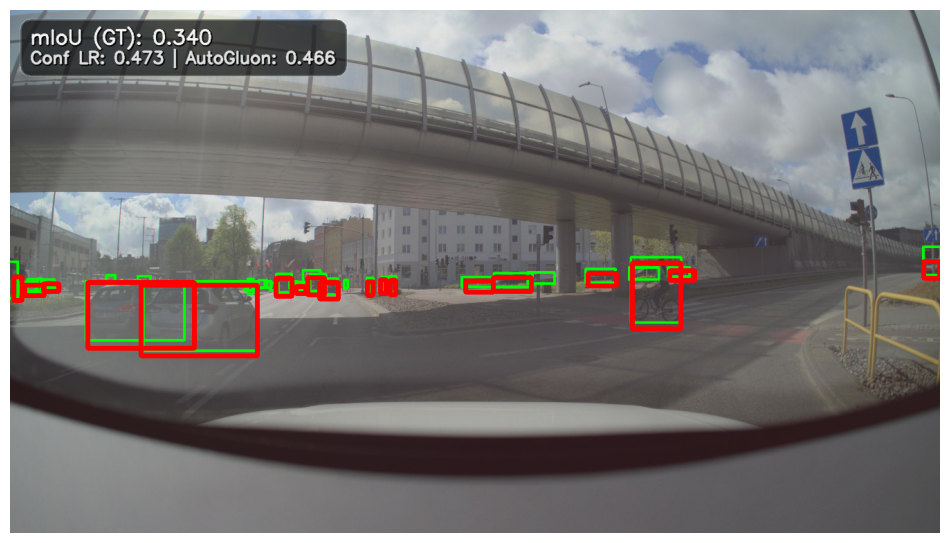

In [115]:
def _rounded_rect(img, pt1, pt2, color, r=12, t=-1):
    x1, y1 = pt1; x2, y2 = pt2
    r = max(0, min(r, (x2 - x1) // 2, (y2 - y1) // 2))
    if t < 0:
        cv2.rectangle(img, (x1 + r, y1), (x2 - r, y2), color, -1)
        cv2.rectangle(img, (x1, y1 + r), (x2, y2 - r), color, -1)
        cv2.circle(img, (x1 + r, y1 + r), r, color, -1)
        cv2.circle(img, (x2 - r, y1 + r), r, color, -1)
        cv2.circle(img, (x1 + r, y2 - r), r, color, -1)
        cv2.circle(img, (x2 - r, y2 - r), r, color, -1)
    else:
        cv2.line(img, (x1 + r, y1), (x2 - r, y1), color, t)
        cv2.line(img, (x1 + r, y2), (x2 - r, y2), color, t)
        cv2.line(img, (x1, y1 + r), (x1, y2 - r), color, t)
        cv2.line(img, (x2, y1 + r), (x2, y2 - r), color, t)
        cv2.ellipse(img, (x1 + r, y1 + r), (r, r), 180, 0, 90, color, t)
        cv2.ellipse(img, (x2 - r, y1 + r), (r, r), 270, 0, 90, color, t)
        cv2.ellipse(img, (x1 + r, y2 - r), (r, r), 90, 0, 90, color, t)
        cv2.ellipse(img, (x2 - r, y2 - r), (r, r), 0, 0, 90, color, t)

def draw_pretty_overlay(img, line1, line2, origin=(15, 15)):
    out = img.copy()
    x, y = origin
    font = cv2.FONT_HERSHEY_SIMPLEX

    # text sizing
    s1, th1 = 0.95, 2
    s2, th2 = 0.80, 2
    (w1, h1), _ = cv2.getTextSize(line1, font, s1, th1)
    (w2, h2), _ = cv2.getTextSize(line2, font, s2, th2)

    pad = 14
    gap = 10
    w = max(w1, w2) + 2 * pad
    h = h1 + h2 + gap + 2 * pad + 4

    pt1 = (x, y)
    pt2 = (x + w, y + h)

    # translucent rounded panel
    overlay = out.copy()
    _rounded_rect(overlay, pt1, pt2, (15, 15, 15), r=14, t=-1)
    out = cv2.addWeighted(overlay, 0.72, out, 0.28, 0)

    # subtle border
    border = out.copy()
    _rounded_rect(border, pt1, pt2, (255, 255, 255), r=14, t=2)
    out = cv2.addWeighted(border, 0.18, out, 0.82, 0)

    # text (with tiny shadow for readability)
    tx = x + pad
    ty1 = y + pad + h1
    ty2 = ty1 + gap + h2

    cv2.putText(out, line1, (tx + 1, ty1 + 1), font, s1, (0, 0, 0), th1 + 2, cv2.LINE_AA)
    cv2.putText(out, line2, (tx + 1, ty2 + 1), font, s2, (0, 0, 0), th2 + 2, cv2.LINE_AA)

    cv2.putText(out, line1, (tx, ty1), font, s1, (245, 245, 245), th1, cv2.LINE_AA)
    cv2.putText(out, line2, (tx, ty2), font, s2, (225, 225, 225), th2, cv2.LINE_AA)
    return out


# --- your code, with only the rectangle+putText part replaced ---
rand_ids = np.random.choice(iou_assessor_results.index, size=1, replace=False)
rand_id = int(rand_ids[0])
print(f"Randomly selected frame ID: {rand_id}")

row = iou_assessor_results.loc[rand_id]
baseline_val = float(row["baseline"])
autg_val = float(row["autg"])
gt_val = float(row["GT"])

zod_frame = zod_frames[rand_id]
image = zod_frame.get_image()
image_with_boxes = image.copy()

annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
annotations_2d = [
    annotation.box2d
    for annotation in annotations
    if annotation.name in ["Vehicle", "Pedestrian", "VulnerableVehicle"]
    and str(annotation.occlusion_level) in ["None", "Medium", "Light"]
    and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25
]

for ann in annotations_2d:
    image_with_boxes = overlay_object_2d_box_on_image(
        image_with_boxes, ann, color=(0, 255, 0), line_thickness=10
    )

pred = preds.get(str(rand_id), {"boxes": []})
if pred["boxes"] == []:
    pred = preds.get(f"{rand_id:06}", {"boxes": []})
    if pred["boxes"] == []:
        print(f"No predictions for frame {rand_id}")

image_with_boxes = cv2.resize(image_with_boxes, IMG_SIZE)

for i, box in enumerate(pred["boxes"]):
    if box == []:
        print(f"Missing box for frame {rand_id}, box index {i}")
        continue
    # Fixes type checker error: Box2D expects Camera, not ZodFrame
    box2d = Box2D(xyxy=np.asarray(box), frame=Camera.FRONT)
    image_with_boxes = overlay_object_2d_box_on_image(
        image_with_boxes, box2d, color=(255, 0, 0), line_thickness=5
    )

text_1 = f"mIoU (GT): {gt_val:.3f}"
text_2 = f"Conf LR: {baseline_val:.3f} | AutoGluon: {autg_val:.3f}"

# --- replaced: old cv2.rectangle + putText block ---
image_with_boxes = draw_pretty_overlay(image_with_boxes, text_1, text_2, origin=(15, 15))

plt.figure(figsize=(12, 8))
plt.imshow(image_with_boxes)
plt.axis("off")
plt.show()

# Error analysis

In [12]:
THRESHOLD = 0.5   # Delta between predicte and expected value
TARGET_MODEL = "autg"

## IoU

In [13]:

error_df = iou_assessor_results.copy()
error_df[f"abs_delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL]).abs()
error_df[f"delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL])
high_error = error_df[error_df[f"abs_delta_{TARGET_MODEL}"] > THRESHOLD]

print(f"High-error instances (|GT - {TARGET_MODEL}| > {THRESHOLD}): {len(high_error)}")
display(high_error[["GT", TARGET_MODEL, f"abs_delta_{TARGET_MODEL}", f"delta_{TARGET_MODEL}"]].head(10))

High-error instances (|GT - autg| > 0.5): 19


,GT,autg,abs_delta_autg,delta_autg
29454,0.144886,0.656870,0.511984,-0.511984
33405,0.950460,0.280509,0.669951,0.669951
42529,0.130507,0.728232,0.597725,-0.597725
53563,0.000000,0.534820,0.534820,-0.534820
57471,0.238306,0.880323,0.642018,-0.642018
62199,0.134426,0.802641,0.668216,-0.668216
64819,0.000000,0.678729,0.678729,-0.678729
70224,0.000000,0.711429,0.711429,-0.711429
71495,0.766875,0.115513,0.651363,0.651363
72396,0.748597,0.159670,0.588927,0.588927


In [14]:
imgs_good_gt = []
id_good_gt = []
imgs_bad_gt = []
id_bad_gt = []
missing = []
for frame_id in high_error.index:
    zod_frame = zod_frames[frame_id]
    image = zod_frame.get_image() 
    annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
    annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and str(annotation.occlusion_level) in ["None", "Medium", "Light"] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]
    #annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]

    for ann in annotations_2d:
        image_with_boxes = overlay_object_2d_box_on_image(image,ann, color=(0, 255, 0), line_thickness=10)

    pred = preds.get(str(frame_id), {"boxes": []})
    if pred["boxes"] == []:
        pred = preds.get(f"{frame_id:06}", {"boxes": []})
        if pred["boxes"] == []:
            print(f"No predictions for frame {frame_id}")
    
    image_with_boxes = cv2.resize(image_with_boxes, IMG_SIZE)
    
    for i, box in enumerate(pred["boxes"]):
        if box == []:
            print(f"Missing box for frame {frame_id}, box index {i}")
        box2d = Box2D(xyxy=np.asarray(box), frame=zod_frame)
        image_with_boxes = overlay_object_2d_box_on_image(image_with_boxes, box2d, color=(255, 0, 0), line_thickness=5)


    if image_with_boxes is None:
        missing.append(frame_id)

    if high_error.loc[frame_id][f"delta_{TARGET_MODEL}"] > 0:
        imgs_good_gt.append(image_with_boxes)
        id_good_gt.append(frame_id)
    else: 
        imgs_bad_gt.append(image_with_boxes)
        id_bad_gt.append(frame_id)

In [15]:
print(f"Number of images: {len(imgs_good_gt) + len(imgs_bad_gt)}")
print(f"Missing images: {len(missing)} with ids: {sorted(missing)}")

Number of images: 19
Missing images: 0 with ids: []


High IoU, but assessor predicts low IoU

In [16]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_good_gt], imgs_good_gt))
stackview.switch(stack)

In [17]:
display(iou_assessor_results.loc[id_good_gt])

,country,time_of_day,lat,long,solar_angle_elevation,month,hour,forward_acceleration,lateral_acceleration,forward_velocity,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
33405,IT,day,41.827749,12.456725,57.954336,8,12,0.412912,-1.223954,54.485545,...,0.815165,0.111139,0.950460,0.440018,0.478372,0.308419,0.287706,0.335339,0.337517,0.280509
71495,NO,day,63.089543,9.211958,7.458733,2,8,1.214847,-2.402707,62.693417,...,0.568817,0.000000,0.766875,0.212876,0.413147,0.082983,0.198708,0.143036,0.089506,0.115513
72396,NO,day,63.893655,11.433291,11.739160,2,9,0.636224,0.597456,72.918315,...,0.509016,0.000000,0.748597,0.157737,0.373059,0.082983,0.055388,0.099410,0.087901,0.159670
93418,PL,night,54.386136,18.645504,-6.721598,6,20,0.078584,-1.613172,50.332027,...,0.897283,0.000000,0.909367,0.515734,0.537676,0.408686,0.458473,0.427321,0.370238,0.408600
94207,NO,day,63.909726,11.440378,11.624949,2,9,1.781923,-1.335094,66.912756,...,0.583235,0.000000,0.751918,0.226170,0.422018,0.082983,0.253167,0.129485,0.073341,0.144891


IoU low, but assessor predicts high

In [18]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_bad_gt], imgs_bad_gt))
stackview.switch(stack)

In [19]:
display(iou_assessor_results.loc[id_bad_gt])

,country,time_of_day,lat,long,solar_angle_elevation,month,hour,forward_acceleration,lateral_acceleration,forward_velocity,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
29454,FR,day,43.317642,5.363112,33.945557,2,13,0.049056,-1.469878,58.010831,...,0.990126,0.0,0.144886,0.601340,0.642602,0.640564,0.694661,0.736069,0.661814,0.656870
42529,PL,day,52.196019,20.976346,47.751762,4,9,0.723773,-0.386893,3.193369,...,0.999837,0.0,0.130507,0.610293,0.573123,0.837728,0.776916,0.620491,0.778176,0.728232
53563,FR,day,43.743589,7.378304,18.193578,2,8,0.908339,-0.173526,0.012647,...,0.969461,0.0,0.000000,0.582285,0.567014,0.490029,0.497147,0.621218,0.437750,0.534820
57471,NO,day,64.110437,11.390606,9.939558,2,9,3.304029,-1.415529,28.516217,...,0.999944,0.0,0.238306,0.610392,0.688719,0.837728,0.806999,0.823423,0.900709,0.880323
62199,FR,day,45.752905,4.853542,17.705232,2,15,3.075294,-6.423673,16.210912,...,0.999858,0.0,0.134426,0.610312,0.603862,0.837728,0.787978,0.741231,0.813265,0.802641
64819,SE,day,63.001204,16.112351,6.765931,2,13,0.388280,-0.417417,66.101497,...,0.985872,0.0,0.000000,0.597417,0.696200,0.578073,0.668393,0.772642,0.726486,0.678729
70224,SE,twilight,64.670156,17.837229,-1.455109,1,14,-0.483194,-0.742203,-0.014161,...,0.986067,0.0,0.000000,0.597597,0.610128,0.490029,0.549843,0.682709,0.616967,0.711429
83738,DE,night,49.313849,8.629426,-9.848207,10,17,1.207585,-0.423249,99.186919,...,0.999770,0.0,0.113588,0.610231,0.636812,0.837728,0.831538,0.678097,0.860066,0.749754
84327,SE,night,59.936175,16.853328,-10.890756,5,21,-0.358973,0.601783,68.773952,...,0.918104,0.0,0.000000,0.534932,0.614251,0.522771,0.568207,0.646018,0.561764,0.578165
85457,DE,night,53.010370,12.587314,-9.681879,9,18,0.238428,-1.154811,128.525322,...,0.997603,0.0,0.072087,0.608233,0.682391,0.736374,0.714754,0.729733,0.686738,0.651052


## LRP

In [20]:
lrp_error_df = lrp_assessor_results.copy()
lrp_error_df[f"abs_delta_{TARGET_MODEL}"] = (lrp_error_df["GT"] - lrp_error_df[TARGET_MODEL]).abs()
lrp_error_df[f"delta_{TARGET_MODEL}"] = (lrp_error_df["GT"] - lrp_error_df[TARGET_MODEL])
lrp_high_error = lrp_error_df[lrp_error_df[f"abs_delta_{TARGET_MODEL}"] > THRESHOLD]

print(f"High-error instances (|GT - {TARGET_MODEL}| > {THRESHOLD}): {len(lrp_high_error)}")
display(lrp_high_error[["GT", TARGET_MODEL, f"abs_delta_{TARGET_MODEL}", f"delta_{TARGET_MODEL}"]].head(10))

High-error instances (|GT - autg| > 0.5): 10


,GT,autg,abs_delta_autg,delta_autg
33405,0.900920,0.231640,0.669280,0.669280
42529,0.118157,0.699435,0.581277,-0.581277
57471,0.226611,0.844800,0.618189,-0.618189
62199,0.125994,0.693036,0.567042,-0.567042
70224,0.000000,0.554414,0.554414,-0.554414
83738,0.102176,0.642994,0.540817,-0.540817
85457,0.000000,0.552174,0.552174,-0.552174
86913,0.220027,0.794586,0.574560,-0.574560
93418,0.818734,0.249090,0.569643,0.569643
94901,0.868493,0.291895,0.576598,0.576598


In [21]:
imgs_good_gt_lrp = []
id_good_gt_lrp = []
imgs_bad_gt_lrp = []
id_bad_gt_lrp = []
missing_lrp = []
for frame_id in lrp_high_error.index:
    zod_frame = zod_frames[frame_id]
    image = zod_frame.get_image() 
    annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
    annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and str(annotation.occlusion_level) in ["None", "Medium"] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]

    for ann in annotations_2d:
        image_with_boxes = overlay_object_2d_box_on_image(image,ann, color=(0, 255, 0), line_thickness=10)

    pred = preds.get(str(frame_id), {"boxes": []})
    if pred["boxes"] == []:
        pred = preds.get(f"{frame_id:06}", {"boxes": []})
        if pred["boxes"] == []:
            print(f"No predictions for frame {frame_id}")
    for i, box in enumerate(pred["boxes"]):
        if box == []:
            print(f"Missing box for frame {frame_id}, box index {i}")
        box2d = Box2D(xyxy=np.asarray(box), frame=zod_frame)
        image_with_boxes = overlay_object_2d_box_on_image(image_with_boxes, box2d, color=(255, 0, 0), line_thickness=5)


    if image_with_boxes is None:
        missing_lrp.append(frame_id)

    image_with_boxes = cv2.resize(image_with_boxes, IMG_SIZE)

    if lrp_high_error.loc[frame_id][f"delta_{TARGET_MODEL}"] > 0:
        imgs_good_gt_lrp.append(image_with_boxes)
        id_good_gt_lrp.append(frame_id)
    else: 
        imgs_bad_gt_lrp.append(image_with_boxes)
        id_bad_gt_lrp.append(frame_id)

In [22]:
print(f"Number of images: {len(imgs_good_gt_lrp) + len(imgs_bad_gt_lrp)} with id {high_error.index}")
print(f"Missing images: {len(missing_lrp)} with ids: {sorted(missing_lrp)}")

Number of images: 10 with id Index([29454, 33405, 42529, 53563, 57471, 62199, 64819, 70224, 71495, 72396,
       83738, 84327, 85457, 86913, 93418, 93492, 94207, 94448, 97178],
      dtype='int64')
Missing images: 0 with ids: []


In [23]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_good_gt_lrp], imgs_good_gt_lrp))
stackview.switch(stack)

In [24]:
display(lrp_assessor_results.loc[id_good_gt_lrp])

,country,time_of_day,lat,long,solar_angle_elevation,month,hour,forward_acceleration,lateral_acceleration,forward_velocity,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
33405,IT,day,41.827749,12.456725,57.954336,8,12,0.412912,-1.223954,54.485545,...,0.815165,0.111139,0.900920,0.323025,0.389816,0.194261,0.204191,0.228327,0.218174,0.231640
93418,PL,night,54.386136,18.645504,-6.721598,6,20,0.078584,-1.613172,50.332027,...,0.897283,0.000000,0.818734,0.392154,0.425171,0.293670,0.288050,0.222944,0.263716,0.249090
94901,SE,day,65.538260,21.812504,9.205293,3,15,0.102741,-1.460640,88.179232,...,0.828691,0.000000,0.868493,0.334412,0.487514,0.348806,0.337607,0.305209,0.367052,0.291895


In [25]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_bad_gt_lrp], imgs_bad_gt_lrp)) 
stackview.switch(stack)

In [26]:
display(lrp_assessor_results.loc[id_bad_gt_lrp])

,country,time_of_day,lat,long,solar_angle_elevation,month,hour,forward_acceleration,lateral_acceleration,forward_velocity,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
42529,PL,day,52.196019,20.976346,47.751762,4,9,0.723773,-0.386893,3.193369,...,0.999837,0.0,0.118157,0.478486,0.461784,0.770167,0.772408,0.475177,0.736309,0.699435
57471,NO,day,64.110437,11.390606,9.939558,2,9,3.304029,-1.415529,28.516217,...,0.999944,0.0,0.226611,0.478576,0.594020,0.770167,0.780972,0.681096,0.866568,0.844800
62199,FR,day,45.752905,4.853542,17.705232,2,15,3.075294,-6.423673,16.210912,...,0.999858,0.0,0.125994,0.478503,0.498710,0.770167,0.770213,0.611615,0.727594,0.693036
70224,SE,twilight,64.670156,17.837229,-1.455109,1,14,-0.483194,-0.742203,-0.014161,...,0.986067,0.0,0.000000,0.466894,0.484338,0.387442,0.431843,0.547212,0.488022,0.554414
83738,DE,night,49.313849,8.629426,-9.848207,10,17,1.207585,-0.423249,99.186919,...,0.999770,0.0,0.102176,0.478430,0.501093,0.770167,0.771082,0.535725,0.727088,0.642994
85457,DE,night,53.010370,12.587314,-9.681879,9,18,0.238428,-1.154811,128.525322,...,0.997603,0.0,0.000000,0.476605,0.549315,0.637562,0.578862,0.570154,0.592816,0.552174
86913,SE,day,63.699394,20.035110,8.480371,3,15,0.074349,-1.498018,92.363297,...,0.999883,0.0,0.220027,0.478525,0.604422,0.770167,0.780280,0.651877,0.750581,0.794586


## Same Errors?

In [27]:
common_good_ids = set(id_good_gt).intersection(set(id_good_gt_lrp))
total_good_gt = len(set(id_good_gt).union(set(id_good_gt_lrp)))
not_common_good_ids = set(id_good_gt).symmetric_difference(set(id_good_gt_lrp))
print(f"Common good GT high-error IDs between IOU and LRP assessors: {common_good_ids}, in percentage: {len(common_good_ids)/total_good_gt*100:.2f}%")
print(f"IDS not common in good GT high-error: {not_common_good_ids} \n")

common_wrong_ids = set(id_bad_gt).intersection(set(id_bad_gt_lrp))
total_wrong_gt = len(set(id_bad_gt).union(set(id_bad_gt_lrp)))
not_common_wrong_ids = set(id_bad_gt).symmetric_difference(set(id_bad_gt_lrp))
print(f"Common wrong GT high-error IDs between IOU and LRP assessors: {common_wrong_ids}, in percentage: {len(common_wrong_ids)/total_wrong_gt*100:.2f}%")
print(f"IDS not common in wrong GT high-error: {not_common_wrong_ids}")

Common good GT high-error IDs between IOU and LRP assessors: {93418, 33405}, in percentage: 33.33%
IDS not common in good GT high-error: {71495, 72396, 94901, 94207} 

Common wrong GT high-error IDs between IOU and LRP assessors: {42529, 86913, 70224, 85457, 62199, 83738, 57471}, in percentage: 50.00%
IDS not common in wrong GT high-error: {84327, 29454, 94448, 64819, 93492, 97178, 53563}


# Regression Reliability Plots

Calibration curves but for regression. 

In [28]:
def plot_calibration_curve(y_true, y_pred, bin_size=0.1, metric: str = "IoU", ax=None, label=None, iden_line: bool = True):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    avg_predicted = []
    avg_observed = []
    err_low = []
    err_high = []
    rng = np.random.default_rng(0)
    alpha = (1.0 - 0.95) / 2.0    #95% CI

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue
        avg_predicted.append((bins[i - 1] + bins[i]) / 2)  # Center of bin, so it is not influenced by the data
        avg_observed.append(float(np.median(y_true[mask])))   # Mean of observed IoU

        if 300 > 0: #Bootstrap CI
            boots = np.empty(300)
            n = y_true[mask].size
            for b in range(300):
                boots[b] = np.median(rng.choice(y_true[mask], size=n, replace=True))
            lo = np.quantile(boots, alpha)
            hi = np.quantile(boots, 1.0 - alpha)
            #err_low.append(float(np.median(y_true[mask])) - lo)
            err_low.append(lo)
            #err_high.append(hi - float(np.median(y_true[mask])))
            err_high.append(hi)
        else:
            err_low.append(np.nan)
            err_high.append(np.nan)
    
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    if iden_line:
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Perfect')
    ax.plot(avg_predicted, avg_observed, marker='o', label=label or 'Model')
    ax.fill_between(avg_predicted, err_low, err_high, alpha=0.15)
    #ax.errorbar(avg_predicted,avg_observed,yerr=np.vstack([err_low, err_high]),fmt='o-',capsize=3,label=label or 'Model')
    ax.set_xlabel(f'Predicted {metric} (bin center)')
    ax.set_ylabel(f'Observed {metric} (median)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    if label is not None:
        ax.legend()
    return ax


def plot_inst_per_bin(y_pred, bin_size=0.1, ax=None, label=None, alpha=1.0, linestyle='-', fill="///", fillcolor="black"):
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    n_instances = []
    bin_centers = [] 
    for i in range(1, len(bins)):
        mask = bin_ids == i
        n = np.count_nonzero(mask)
        n_instances.append(n)
        bin_centers.append((bins[i - 1] + bins[i]) / 2)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.bar(bin_centers, height=n_instances, width=bin_size, label=label or 'Model', alpha=alpha, linestyle=linestyle, hatch=fill, edgecolor='black', color=fillcolor)
    ax.set_xlabel('Bins')
    ax.set_ylabel('Nº of instances')
    if label is not None:
        ax.legend()
    return ax

In [29]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

## IoU

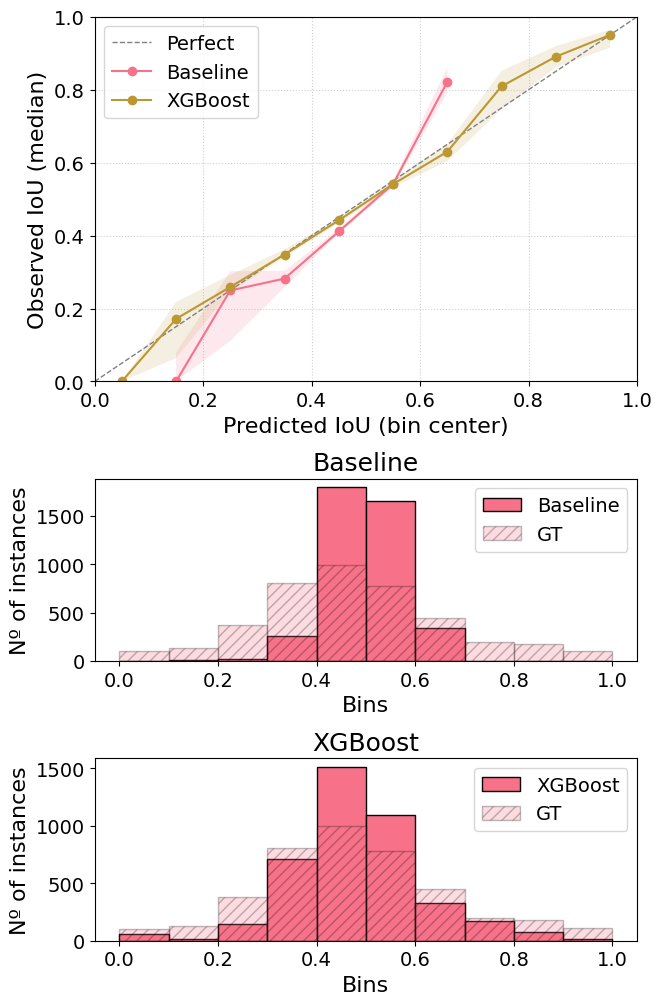

In [30]:
fig = plt.figure(figsize=(7, 12))
gs = GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.4, wspace=0.1)
ax_cal = fig.add_subplot(gs[0, :])

plot_calibration_curve(iou_assessor_results["GT"],iou_assessor_results["baseline"],ax=ax_cal,label="Baseline")
plot_calibration_curve(iou_assessor_results["GT"],iou_assessor_results["xgb"],ax=ax_cal,label="XGBoost", iden_line=False)
ax_cal.legend()

ax_baseline = fig.add_subplot(gs[1, 0])
plot_inst_per_bin(iou_assessor_results["baseline"], ax=ax_baseline, label="Baseline", fillcolor="C0", fill=None)
plot_inst_per_bin(iou_assessor_results["GT"], ax=ax_baseline,alpha=0.25, label="GT", fillcolor="C0", fill="///")
ax_baseline.set_title("Baseline")
ax_rf = fig.add_subplot(gs[2, 0])
plot_inst_per_bin(iou_assessor_results["xgb"], ax=ax_rf, label="XGBoost", fillcolor="C0", fill=None)
plot_inst_per_bin(iou_assessor_results["GT"], ax=ax_rf, alpha=0.25,label="GT", fillcolor="C0", fill="///")
ax_rf.set_title("XGBoost")

plt.savefig(f"./plots/{model}_iou_baseline_vs_autog_calib_curve.svg", dpi=200, bbox_inches='tight')
plt.show()

## LRP

/tmp/ipykernel_2773434/171404125.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


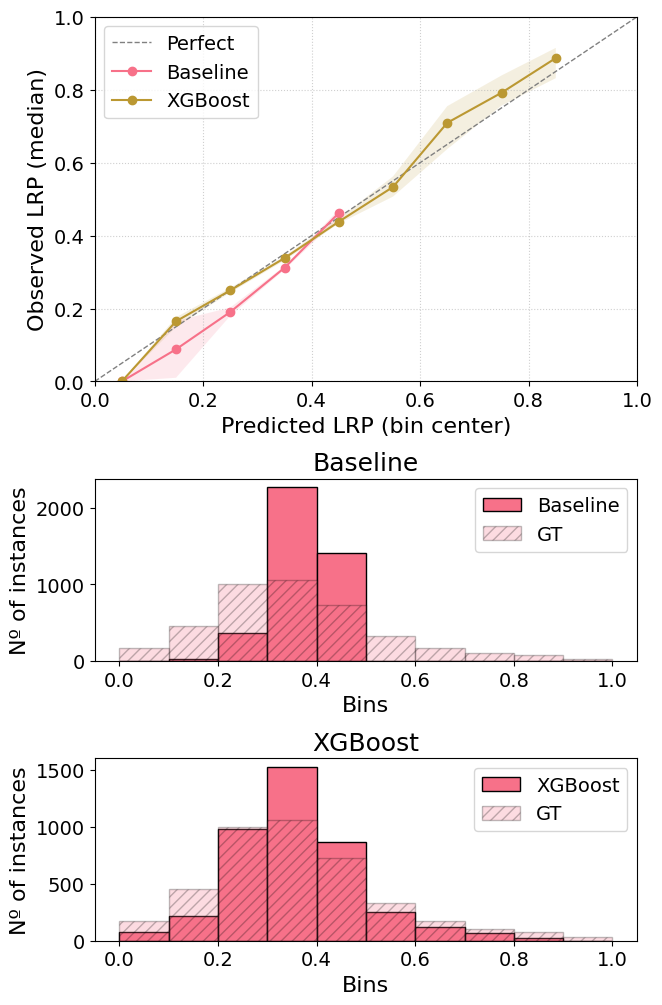

In [31]:
fig = plt.figure(figsize=(7, 12))
gs = GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.4, wspace=0.1)
ax_cal = fig.add_subplot(gs[0, :])

plot_calibration_curve(lrp_assessor_results["GT"], lrp_assessor_results["baseline"], ax=ax_cal, label="Baseline", metric="LRP")
plot_calibration_curve(lrp_assessor_results["GT"], lrp_assessor_results["xgb"], ax=ax_cal, label="XGBoost", iden_line=False, metric="LRP")
ax_cal.legend()

ax_baseline = fig.add_subplot(gs[1, 0])
plot_inst_per_bin(lrp_assessor_results["baseline"], ax=ax_baseline, label="Baseline", fillcolor="C0", fill="")
plot_inst_per_bin(lrp_assessor_results["GT"], ax=ax_baseline, label="GT", alpha=0.25, fillcolor="C0", fill="///")
ax_baseline.set_title("Baseline")

ax_autg = fig.add_subplot(gs[2, 0])
plot_inst_per_bin(lrp_assessor_results["xgb"], ax=ax_autg, label="XGBoost", fillcolor="C0", fill="")
plot_inst_per_bin(lrp_assessor_results["GT"], ax=ax_autg, label="GT", alpha=0.25, fillcolor="C0", fill="///")
ax_autg.set_title("XGBoost")

plt.tight_layout()
plt.savefig(f"./plots/{model}_lrp_baseline_vs_autog_calib_curve.svg", dpi=200, bbox_inches='tight')
plt.show()

# AUROC

For the AUROC we need to discretize the task to binary by setting a treshold. This is not ideal as we are deleting information. So not very useful. 

In [32]:
def plot_auroc(y_true_iou, y_pred, threshold=0.5, ax=None, label=None):
    y_true_iou = np.asarray(y_true_iou)
    y_pred = np.asarray(y_pred)
    success = (y_true_iou > threshold).astype(int)

    fpr, tpr, _ = roc_curve(success, y_pred)
    roc_auc = auc(fpr, tpr)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random')
    ax.plot(fpr, tpr, label=label or f'AUROC = {roc_auc:.3f}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    return ax, roc_auc

## IoU

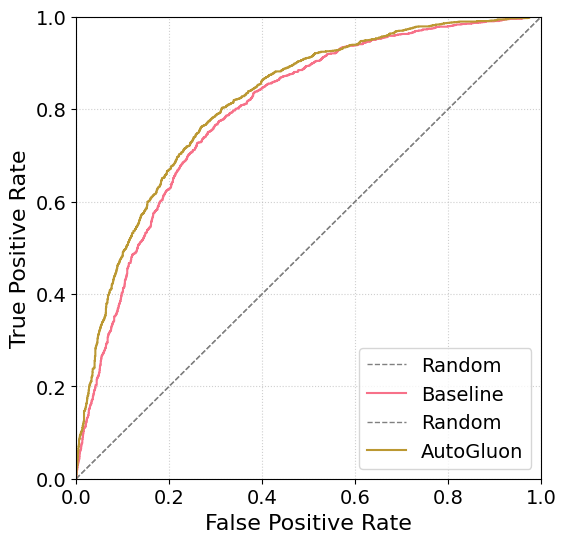

In [33]:
fig, ax = plt.subplots(figsize=(6, 6))
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["baseline"], threshold=0.5, ax=ax, label="Baseline")
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["autg"], threshold=0.5, ax=ax, label="AutoGluon")
ax.legend()

## Gated Evaluation (Selective Prediction)

No worries — “risk–coverage” is just **“how good are we on the frames we decide to trust?”**

Think of your validator as a **trust knob**:

- It predicts $\hat V(I)$: how good the detector will be on a frame.
- You can **trust** (normal pipeline) vs **abstain** (fallback, slow down, log, etc.).

**Coverage** = fraction of frames kept/trusted.  \
**Risk** = error on kept frames.

For $V \in \{\text{meanIoU}, \text{LRP}\}$ (higher is better), we define:

- risk $= 1 - \mathbb{E}[V \mid \text{kept}]$ (lower is better)

**Procedure**

1. Sort frames by predicted validity $\hat V_i$ (descending).
2. Choose coverage levels $c \in \{100, 90, 80, 70, 60\}\%$.
3. For each coverage $c$, keep top-$c\%$ frames and compute:
   - kept-set mean: $\mathbb{E}[V \mid \text{kept}]$
   - (optional) 10th percentile: $Q_{0.10}(V \mid \text{kept})$

**Baselines to compare**

- confidence-only baseline
- best validator (e.g., AutoGluon / XGBoost)
- random ranking (sanity check)
- (optional) MetaDetect if available


In [34]:
# Simple gated evaluation (meanIoU)
import numpy as np
import pandas as pd

coverage_levels = [80, 50, 20, 10]

validator_candidates = ["autg", "xgb", "rf", "mlp", "dt", "lr"]
validator = "autg"

def kept_mean(df, score_col, c):
    sub = df[["GT", score_col]].dropna()
    k = max(1, int(np.ceil(len(sub) * c / 100)))
    kept = sub.sort_values(score_col, ascending=False).head(k)["GT"]
    return float(kept.mean())

rows = []
for c in coverage_levels:
    rows.append({
        "Coverage (kept)": c,
        "Avg true meanIoU using confidence": kept_mean(iou_assessor_results, "lr", c),
        f"Avg true meanIoU using validator ({validator})": kept_mean(iou_assessor_results, validator, c),
    })

simple_table = pd.DataFrame(rows).sort_values("Coverage (kept)", ascending=False)
display(simple_table)


,Coverage (kept),Avg true meanIoU using confidence,Avg true meanIoU using validator (autg)
0,80,0.518766,0.520175
1,50,0.571432,0.574321
2,20,0.653398,0.658854
3,10,0.722422,0.723747
